# Analise Exploratória de Dados

#### Imortanto lib e Carregando o dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [6]:
df = pd.read_parquet(
    'dataset_gold.parquet',
    engine='fastparquet'
)
df.head()

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,price,preco_usd,tempo_total_horas,custo_hora,owners_medio,steam_rating,custo_hora_norm,steam_rating_norm,score_cb,retencao,hidden_gem
0,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",3854,835,2999,29.99,64.23,0.47,75000000.0,0.9410,0.0005,0.9307,0.9651,0.2167,0
1,1938090,Call of Duty: Modern Warfare II,"Treyarch, Raven Software, Beenox, High Moon St...",Activision,419594,294520,"50,000,000 .. 100,000,000",5397,639,3849,38.49,89.95,0.43,75000000.0,0.5876,0.0004,0.5156,0.7576,0.1184,0
2,1063730,New World: Aeternum,Amazon Games,Amazon Games,196798,90080,"50,000,000 .. 100,000,000",10588,18,5999,59.99,176.47,0.34,75000000.0,0.6860,0.0003,0.6312,0.8154,0.0017,0
3,2358720,Black Myth: Wukong,Game Science,Game Science,1111720,38378,"50,000,000 .. 100,000,000",3268,524,5999,59.99,54.47,1.10,75000000.0,0.9666,0.0011,0.9608,0.9798,0.1603,0
4,550,Left 4 Dead 2,Valve,Valve,940221,23762,"50,000,000 .. 100,000,000",2479,352,999,9.99,41.32,0.24,75000000.0,0.9754,0.0002,0.9711,0.9854,0.1420,0


## Visão Geral do Dataset

#### Resumo estatístico

In [7]:
df.describe()

,appid,positive,negative,average_forever,average_2weeks,price,preco_usd,tempo_total_horas,custo_hora,owners_medio,steam_rating,custo_hora_norm,steam_rating_norm,score_cb,retencao,hidden_gem
count,7.166000e+03,7.166000e+03,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000,7.166000e+03,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000
mean,8.312383e+05,1.291433e+04,1730.454507,1029.250768,106.659085,1504.619732,15.046197,17.154219,2.972019,8.811471e+05,0.805824,0.002977,0.771933,0.884479,0.106564,0.071867
std,7.028078e+05,5.729950e+04,8188.610636,4235.226678,381.956677,1324.385895,13.243859,70.587130,16.574439,3.067683e+06,0.141401,0.016582,0.166081,0.083834,0.392711,0.258286
min,1.000000e+01,2.000000e+00,0.000000,1.000000,0.000000,27.000000,0.270000,0.020000,0.000000,7.500000e+04,0.148600,0.000000,0.000000,0.177600,0.000000,0.000000
25%,3.063800e+05,6.960000e+02,150.000000,218.000000,0.000000,499.000000,4.990000,3.630000,0.610000,1.500000e+05,0.738325,0.000600,0.692625,0.844600,0.000000,0.000000
50%,5.729750e+05,2.024500e+03,354.500000,387.000000,0.000000,999.000000,9.990000,6.450000,1.430000,3.500000e+05,0.841200,0.001400,0.813500,0.905400,0.000000,0.000000
75%,1.225568e+06,6.252750e+03,971.000000,907.000000,41.000000,1999.000000,19.990000,15.120000,2.970000,7.500000e+05,0.911600,0.003000,0.896200,0.946875,0.049800,0.000000
max,3.431040e+06,1.373979e+06,294520.000000,263340.000000,9872.000000,14999.000000,149.990000,4389.000000,999.500000,7.500000e+07,1.000000,1.000000,1.000000,0.999400,10.884200,1.000000


#### Contagem de jogos por faixa de preço

##### Faixa de Preço

Para facilitar a comparação de custo-benefício entre os jogos, categorizamos
o preço em quatro faixas baseadas no valor em dólares:

| Faixa | Intervalo |
|-------|-----------|
| Até \$5 | jogos de entrada, geralmente indies |
| \$5–\$15 | faixa intermediária mais popular |
| \$15–\$30 | títulos mid-range |
| Acima de \$30 | jogos premium e AAA |

A contagem abaixo mostra como os jogos se distribuem entre as faixas,
revelando quais segmentos de preço dominam o catálogo analisado.

In [11]:

bins   = [0, 5, 15, 30, float('inf')]
labels = ['Até $5', '$5–$15', '$15–$30', 'Acima de $30']

df['faixa_preco'] = pd.cut(
    df['preco_usd'],
    bins=bins,
    labels=labels,
    right=False
)

print(df['faixa_preco'].value_counts())

faixa_preco
$5–$15          2583
Até $5          2019
$15–$30         1941
Acima de $30     623
Name: count, dtype: int64


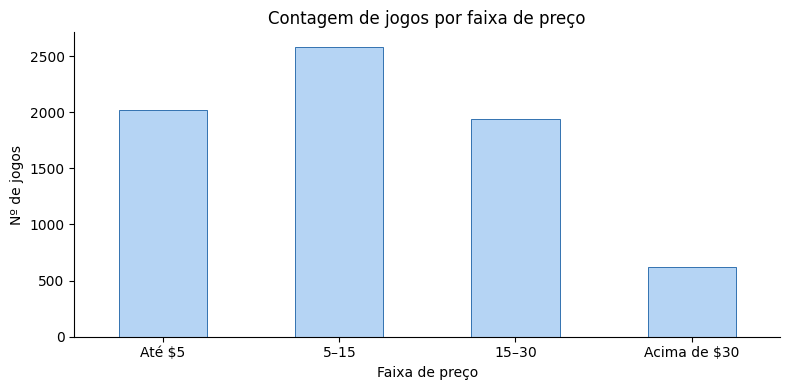

In [12]:
contagem = df['faixa_preco'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4))
contagem.plot(kind='bar', ax=ax, color='#B5D4F4',
              edgecolor='#185FA5', linewidth=0.6)

ax.set_xlabel('Faixa de preço')
ax.set_ylabel('Nº de jogos')
ax.set_title('Contagem de jogos por faixa de preço')
ax.set_xticklabels(labels, rotation=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

O gráfico mostra que a faixa ```$5–$15``` concentra o maior número de jogos (2.583 títulos), seguida de perto por ```Até $5``` (2.019) e ```$15–$30``` (1.941). Juntas, essas três faixas representam cerca de 92% do catálogo analisado. Os jogos ```Acima de $30``` são minoria, com apenas 623 títulos — o que reflete o perfil acessível da plataforma Steam, onde jogos indie e de médio porte dominam a oferta.

#### Distribuição do ```score_cb```

## Q1: Custo-Benefício por faixa de preço

A relação entre preço, tempo médio de jogo e avaliação dos usuários permite identificar diferenças claras de custo-benefício entre os títulos pagos na Steam?

## Q2 : Identificação de Hidden Gems

É possível identificar, entre os jogos com menor número de proprietários, títulos com alto custo-benefício que possam ser considerados hidden gems?

## Q3: Custo-Benefício e Retensão de Jogadores

Jogos com melhor custo-benefício tendem a apresentar maior retenção de
jogadores ao longo do tempo?